In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display

In [35]:
Ag = float(input("Enter gross area (square inches): "))
Ae = float(input("Enter effective net area (square inches): "))
Fy = float(input("Enter specified minimum yield strength (ksi): "))
Fu = float(input("Enter specified minimum ultimate strength (ksi): "))

def nom_yield(Ag, Fy):
    Pn1 = Ag*Fy
    return(Pn1)
def nom_rupture(Ae, Fu):
    Pn2 = Ae*Fu
    return(Pn2)
def design_yield(Pn1):
    DY = Pn1*.9
    return(DY)
def design_rupture(Pn2):
    DR = Pn2*.75
    return(DR)
def allow_yield(Pn1):
    AY = Pn1/1.67
    return(AY)
def allow_rupture(Pn2):
    AR = Pn2/2
    return(AR)
def true_design(DY, DR):
    if DY < DR:
        return(DY)
    else:
        return(DR)
def true_allow(AY, AR):
    if AY < AR:
        return(AY)
    else:
        return(AR)

print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
Pn1 = nom_yield(Ag, Fy)
print(f"Nominal yield strength: {Pn1} kilopounds")
Pn2 = nom_rupture(Ae, Fu)
print(f"Nominal rupture strength: {Pn2} kilopounds")
print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
DY = design_yield(Pn1)
print(f"Design tensile yield: {DY} kilopounds")
AY = allow_yield(Pn1)
print(f"Allowable tensile yield: {AY} kilopounds")
print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
DR = design_rupture(Pn2)
print(f"Design tensile rupture: {DR} kilopounds")
AR = allow_rupture(Pn2)
print(f"Allowable tensile rupture: {AR} kilopounds")
print(f"~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
TD = true_design(DY, DR)
print(f"Design tensile strength: {TD} kilopounds")
TA = true_allow(AY, AR)
print(f"Allowable tensile strength: {TA} kilopounds")

Enter gross area (square inches):  10
Enter effective net area (square inches):  7.5
Enter specified minimum yield strength (ksi):  50
Enter specified minimum ultimate strength (ksi):  65


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Nominal yield strength: 500.0 kilopounds
Nominal rupture strength: 487.5 kilopounds
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Design tensile yield: 450.0 kilopounds
Allowable tensile yield: 299.4011976047904 kilopounds
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Design tensile rupture: 365.625 kilopounds
Allowable tensile rupture: 243.75 kilopounds
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Design tensile strength: 365.625 kilopounds
Allowable tensile strength: 243.75 kilopounds


In [32]:
Area = pd.read_csv('Area Variance in W-Shaped Tension Members - Cleaned Data.csv')
Grade = pd.read_csv('Variance in Steel Grade for W-Shaped Tension Members - Cleaned Data.csv')

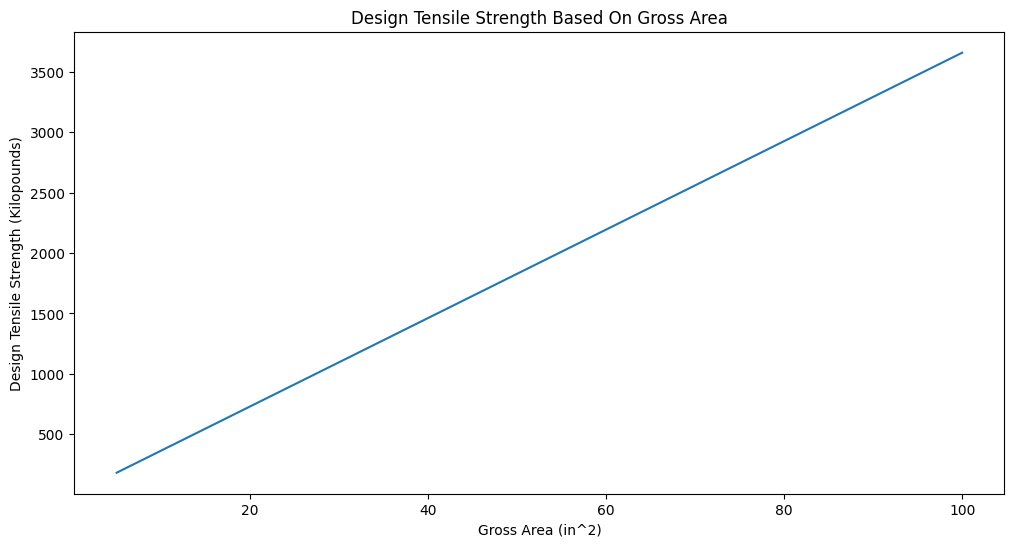

In [28]:
Ag_data = Area['Ag'].values
An_data = Area['An'].values

Set1 = nom_yield(Ag_data, 50)
Set2 = nom_rupture(An_data, 65)

Set3 = design_yield(Set1)
Set4 = design_rupture(Set2)
Set5 = [min(a,b) for a,b in zip(Set3, Set4)]

plt.figure(figsize = (12,6))
plt.plot(Ag_data, Set5)
plt.ylabel('Design Tensile Strength (Kilopounds)')
plt.xlabel('Gross Area (in^2)')
plt.title('Design Tensile Strength Based On Gross Area')
plt.show()

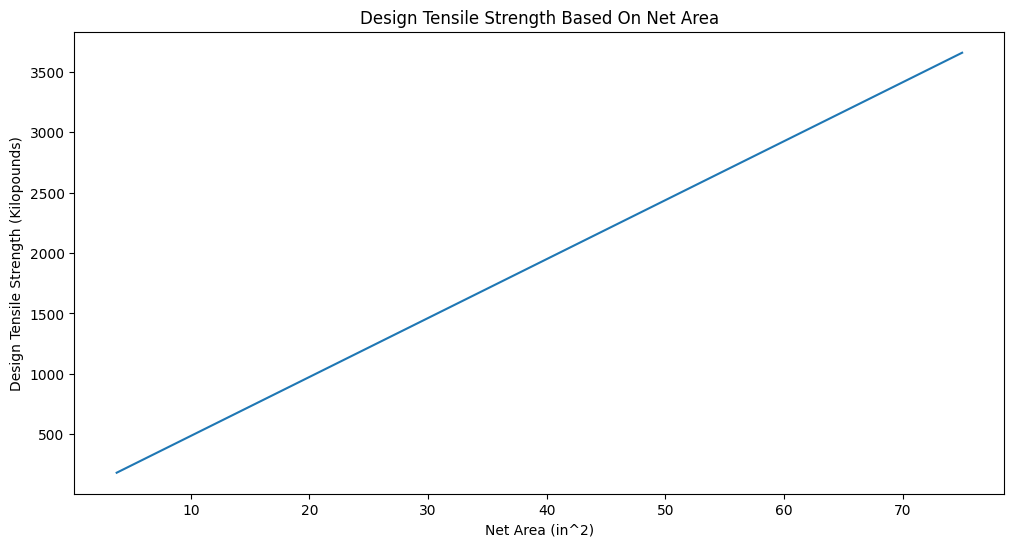

In [29]:
plt.figure(figsize = (12,6))
plt.plot(An_data, Set5)
plt.ylabel('Design Tensile Strength (Kilopounds)')
plt.xlabel('Net Area (in^2)')
plt.title('Design Tensile Strength Based On Net Area')
plt.show()

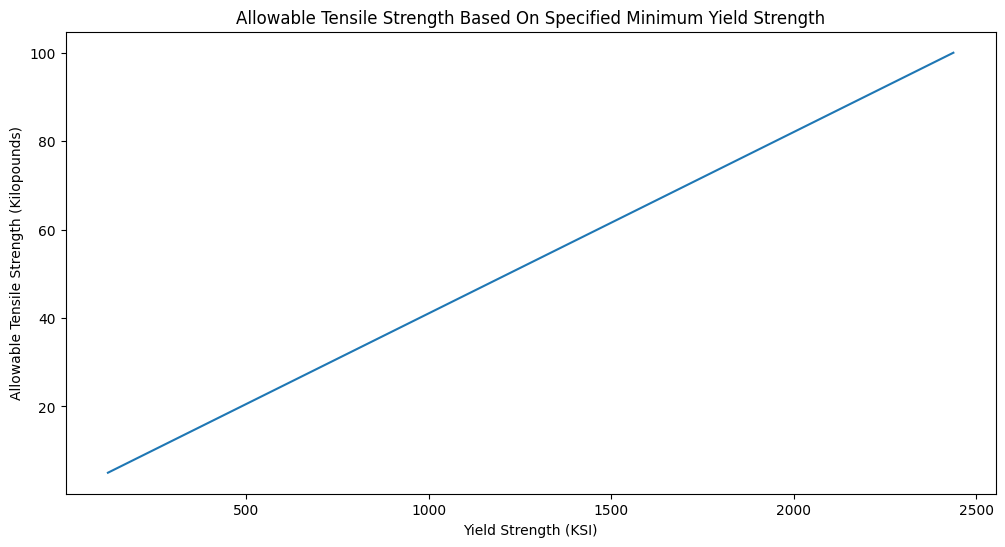

In [36]:
Fy_data = Grade['Fy'].values
Fu_data = Grade['Fu'].values

Test1 = nom_yield(50, Fy_data)
Test2 = nom_rupture(37.5, Fu_data)

Test3 = allow_yield(Test1)
Test4 = allow_rupture(Test2)
Test5 = [min(a,b) for a,b in zip(Test3, Test4)]

plt.figure(figsize = (12,6))
plt.plot(Test5, Fy_data)
plt.ylabel('Allowable Tensile Strength (Kilopounds)')
plt.xlabel('Yield Strength (KSI)')
plt.title('Allowable Tensile Strength Based On Specified Minimum Yield Strength')
plt.show()

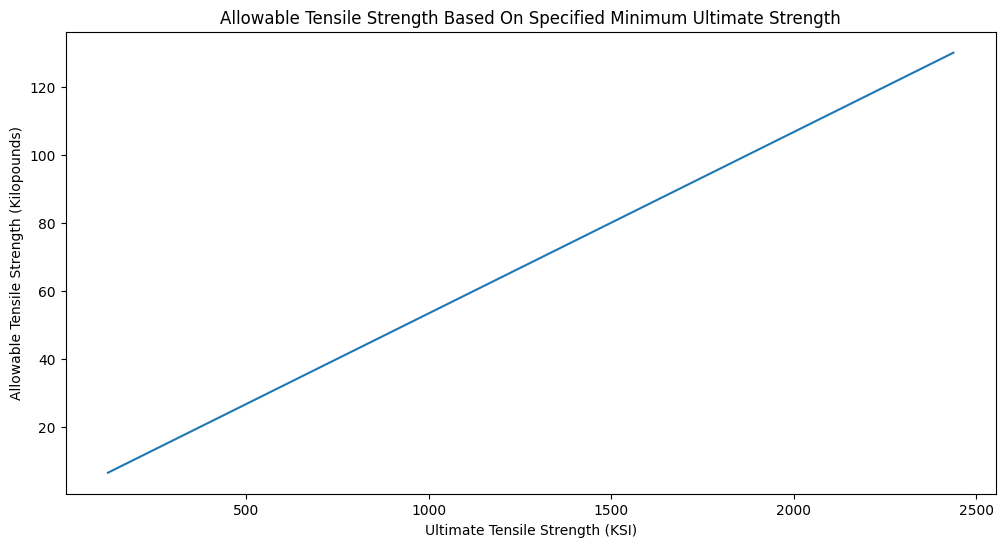

In [37]:
plt.figure(figsize = (12,6))
plt.plot(Test5, Fu_data)
plt.ylabel('Allowable Tensile Strength (Kilopounds)')
plt.xlabel('Ultimate Tensile Strength (KSI)')
plt.title('Allowable Tensile Strength Based On Specified Minimum Ultimate Strength')
plt.show()